# 04 - Weekly Strategy Backtest

Backtest the Clenow-style weekly strategy over a configurable number of weeks. Signals are calculated using data through the prior trading day, and trades execute at the configured weekday open, defaulting to Wednesday.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from clenow.backtest import BacktestConfig, run_backtest
from clenow.data import load_prices
from clenow.ranking import RankingConfig

In [2]:
# Backtest inputs. Edit these before running.
INITIAL_CASH = 100_000.00
WEEKS = 52
TRADE_WEEKDAY = 2  # Monday=0, Tuesday=1, Wednesday=2
INDEX_PROXY = "SPY"
SLIPPAGE_BPS = 5.0
TOP_FRACTION = 0.20
DAILY_MOVE_TARGET = 0.001
GAP_THRESHOLD = 0.15
RISK_REBALANCE_THRESHOLD = 0.20
RISK_REBALANCE_EVERY_N_TRADES = 2
SHOW_PROGRESS = True
PROGRESS_EVERY = 1

In [3]:
PRICES_PATH = PROJECT_ROOT / "data" / "processed" / "sp500_prices.parquet"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"

prices = load_prices(PRICES_PATH)
print(f"Loaded {len(prices):,} rows across {prices['ticker'].nunique()} tickers")
print(f"Date range: {prices['date'].min().date()} to {prices['date'].max().date()}")
if INDEX_PROXY not in set(prices["ticker"]):
    raise ValueError(f"{INDEX_PROXY} is missing. Re-run notebook 01 after adding INDEX_PROXY.")
prices.head()

Loaded 377,954 rows across 504 tickers
Date range: 2023-05-23 to 2026-05-22


,date,ticker,Open,High,Low,Close,Adj Close,Volume
0,2023-05-23,A,129.029999,130.539993,127.910004,128.639999,125.737244,2784400.0
1,2023-05-24,A,115.199997,121.089996,113.279999,120.989998,118.259842,6850400.0
2,2023-05-25,A,121.410004,121.410004,117.639999,119.489998,116.793709,3218900.0
3,2023-05-26,A,120.070000,120.720001,118.379997,120.419998,117.702721,2089100.0
4,2023-05-30,A,120.010002,121.309998,117.669998,117.730003,115.073433,2094800.0


In [4]:
ranking_config = RankingConfig(
    lookback_days=90,
    atr_window=20,
    trend_ma_window=100,
    gap_window=90,
    gap_threshold=None,
    trading_days=252,
    require_positive_slope=True,
    require_above_trend_ma=False,
    min_price=5.0,
    min_avg_dollar_volume=10_000_000.0,
)

config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    weeks=WEEKS,
    trade_weekday=TRADE_WEEKDAY,
    index_proxy=INDEX_PROXY,
    top_fraction=TOP_FRACTION,
    daily_move_target=DAILY_MOVE_TARGET,
    slippage_bps=SLIPPAGE_BPS,
    gap_threshold=GAP_THRESHOLD,
    risk_rebalance_every_n_trades=RISK_REBALANCE_EVERY_N_TRADES,
    risk_rebalance_threshold=RISK_REBALANCE_THRESHOLD,
    show_progress=SHOW_PROGRESS,
    progress_every=PROGRESS_EVERY,
    ranking=ranking_config,
)
config

BacktestConfig(initial_cash=100000.0, weeks=52, trade_weekday=2, index_proxy='SPY', index_trend_ma_window=100, top_fraction=0.2, daily_move_target=0.001, slippage_bps=5.0, gap_threshold=0.15, risk_rebalance_every_n_trades=2, risk_rebalance_threshold=0.2, allow_partial_final_position=False, show_progress=True, progress_every=1, ranking=RankingConfig(lookback_days=90, atr_window=20, trend_ma_window=100, gap_window=90, gap_threshold=None, trading_days=252, require_positive_slope=True, require_above_trend_ma=False, min_price=5.0, min_avg_dollar_volume=10000000.0))

In [5]:
universe = set(prices["ticker"].unique()).difference({INDEX_PROXY})
print(f"Running backtest across {WEEKS} configured weeks...")
result = run_backtest(prices, config=config, universe=universe)

result.equity_curve.to_csv(OUTPUT_DIR / "backtest_equity_curve.csv", index=False)
result.trades.to_csv(OUTPUT_DIR / "backtest_trades.csv", index=False)
result.holdings.to_csv(OUTPUT_DIR / "backtest_holdings.csv", index=False)
result.rebalance_log.to_csv(OUTPUT_DIR / "backtest_rebalance_log.csv", index=False)

print("Backtest complete")
print(f"Equity rows: {len(result.equity_curve):,}")
print(f"Trades: {len(result.trades):,}")
print(f"Holding snapshots: {len(result.holdings):,}")

Running backtest across 52 configured weeks...
[   1/52] 2025-05-28 - equity=$99,950.45, cash=$859.07, positions=21, trades=21
[   2/52] 2025-06-04 - equity=$101,116.14, cash=$417.63, positions=21, trades=23
[   3/52] 2025-06-11 - equity=$99,089.96, cash=$417.63, positions=21, trades=23
[   4/52] 2025-06-18 - equity=$100,950.73, cash=$417.63, positions=21, trades=23
[   5/52] 2025-06-25 - equity=$101,885.29, cash=$2,237.99, positions=21, trades=27
[   6/52] 2025-07-02 - equity=$101,528.22, cash=$842.01, positions=24, trades=42
[   7/52] 2025-07-09 - equity=$102,222.14, cash=$983.23, positions=25, trades=51
[   8/52] 2025-07-16 - equity=$101,639.35, cash=$1,553.37, positions=26, trades=62
[   9/52] 2025-07-23 - equity=$102,466.67, cash=$284.52, positions=27, trades=65
[  10/52] 2025-07-30 - equity=$104,846.93, cash=$3,206.64, positions=28, trades=76
[  11/52] 2025-08-06 - equity=$104,480.80, cash=$1,411.49, positions=29, trades=85
[  12/52] 2025-08-13 - equity=$107,044.13, cash=$10,909.

In [6]:
equity = result.equity_curve.copy()
if equity.empty:
    raise ValueError("Backtest produced no equity rows. Check date range and downloaded history.")

equity["date"] = pd.to_datetime(equity["date"])

index_prices = (
    prices.loc[prices["ticker"].eq(INDEX_PROXY), ["date", "Open", "Adj Close"]]
    .sort_values("date")
    .copy()
)
benchmark = pd.merge_asof(
    equity[["date"]].sort_values("date"),
    index_prices.sort_values("date"),
    on="date",
    direction="backward",
)
benchmark["benchmark_price"] = benchmark["Open"].fillna(benchmark["Adj Close"])
first_benchmark_price = benchmark["benchmark_price"].iloc[0]
equity[f"buy_hold_{INDEX_PROXY}"] = INITIAL_CASH * benchmark["benchmark_price"] / first_benchmark_price


def performance_metrics(frame, column, label, periods_per_year=52):
    series = frame[["date", column]].dropna().copy()
    returns = series[column].pct_change().dropna()
    total_return = series[column].iloc[-1] / series[column].iloc[0] - 1
    years = max((series["date"].iloc[-1] - series["date"].iloc[0]).days / 365.25, 1 / 365.25)
    cagr = (series[column].iloc[-1] / series[column].iloc[0]) ** (1 / years) - 1
    annual_volatility = returns.std() * periods_per_year**0.5
    sharpe = returns.mean() / returns.std() * periods_per_year**0.5 if returns.std() else 0.0
    max_drawdown = (series[column] / series[column].cummax() - 1).min()
    calmar = cagr / abs(max_drawdown) if max_drawdown else 0.0
    return {
        "series": label,
        "final_value": series[column].iloc[-1],
        "total_return": total_return,
        "cagr": cagr,
        "annual_volatility": annual_volatility,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "calmar": calmar,
    }

ratios = pd.DataFrame(
    [
        performance_metrics(equity, "equity", "Strategy"),
        performance_metrics(equity, f"buy_hold_{INDEX_PROXY}", f"Buy & Hold {INDEX_PROXY}"),
    ]
)

summary = ratios.assign(
    trade_count=len(result.trades),
    final_positions=equity["positions"].iloc[-1],
)
summary

,series,final_value,total_return,cagr,annual_volatility,sharpe,max_drawdown,calmar,trade_count,final_positions
0,Strategy,160368.895663,0.604484,0.622111,0.167355,2.975798,-0.063638,9.775846,436,44
1,Buy & Hold SPY,124367.777573,0.243678,0.249961,0.103450,2.204554,-0.061904,4.037904,436,44


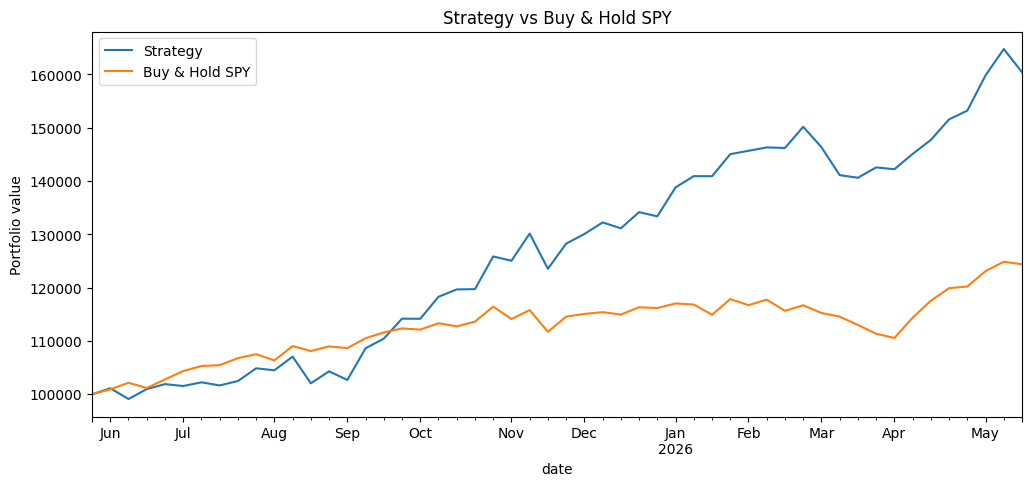

In [7]:
ax = equity.plot(
    x="date",
    y=["equity", f"buy_hold_{INDEX_PROXY}"],
    figsize=(12, 5),
    title=f"Strategy vs Buy & Hold {INDEX_PROXY}",
)
ax.set_ylabel("Portfolio value")
ax.legend(["Strategy", f"Buy & Hold {INDEX_PROXY}"]);

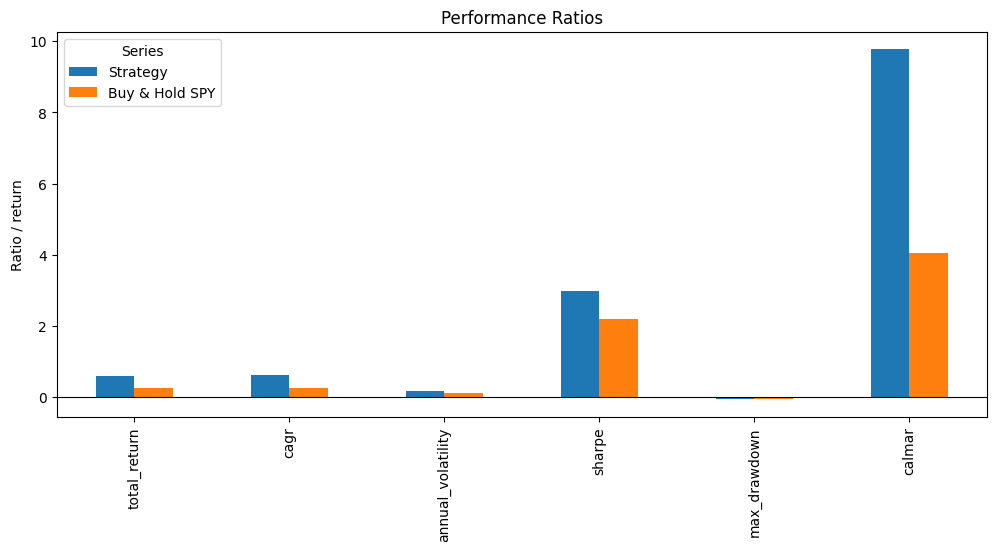

In [8]:
ratio_table = ratios.set_index("series")[[
    "final_value",
    "total_return",
    "cagr",
    "annual_volatility",
    "sharpe",
    "max_drawdown",
    "calmar",
]].copy()

ratio_table.style.format(
    {
        "final_value": "${:,.2f}",
        "total_return": "{:.2%}",
        "cagr": "{:.2%}",
        "annual_volatility": "{:.2%}",
        "sharpe": "{:.2f}",
        "max_drawdown": "{:.2%}",
        "calmar": "{:.2f}",
    }
)

In [9]:
result.trades.tail(50)

,date,ticker,action,shares,price,trade_value,slippage,reason,cash_after
386,2026-04-15,COP,buy,35,118.169998,4135.949936,2.067975,ranked_buy,43218.119050
387,2026-04-15,XOM,buy,26,148.600006,3863.600159,1.931800,ranked_buy,39352.587091
388,2026-04-15,EQIX,buy,7,1059.770020,7418.390137,3.709195,ranked_buy,31930.487759
389,2026-04-15,BG,buy,34,123.019997,4182.679886,2.091340,ranked_buy,27745.716533
390,2026-04-15,CVX,buy,24,186.360001,4472.640015,2.236320,ranked_buy,23270.840199
391,2026-04-15,DVN,buy,82,45.049999,3694.099937,1.847050,ranked_buy,19574.893211
392,2026-04-15,EOG,buy,32,132.839996,4250.879883,2.125440,ranked_buy,15321.887888
393,2026-04-15,MPC,buy,16,222.449997,3559.199951,1.779600,ranked_buy,11760.908337
394,2026-04-15,PWR,buy,7,586.380005,4104.660034,2.052330,ranked_buy,7654.195973
395,2026-04-15,GNRC,buy,15,211.050003,3165.750046,1.582875,ranked_buy,4486.863052


In [10]:
latest_date = result.holdings["date"].max() if not result.holdings.empty else None
latest_holdings = result.holdings.loc[result.holdings["date"].eq(latest_date)].copy() if latest_date is not None else result.holdings
latest_holdings.sort_values("weight", ascending=False).head(50)

,date,ticker,shares,price,market_value,weight,rank,atr_risk
1693,2026-05-20,EQIX,7,1044.839966,7313.879761,0.045607,30,161.160986
1674,2026-05-20,SLB,101,56.869999,5743.869892,0.035817,80,159.428518
1675,2026-05-20,FDX,15,376.850006,5652.750092,0.035248,84,175.890038
1679,2026-05-20,TRGP,19,275.260010,5229.940186,0.032612,33,134.196980
1671,2026-05-20,CAT,6,871.219971,5227.319824,0.032596,37,180.482959
1676,2026-05-20,HAL,116,43.000000,4988.000000,0.031103,40,132.355932
1690,2026-05-20,VLO,19,261.450012,4967.550232,0.030976,31,153.244512
1700,2026-05-20,BKR,72,65.760002,4734.720154,0.029524,57,146.807982
1680,2026-05-20,KEYS,14,330.000000,4620.000000,0.028809,12,159.410986
1696,2026-05-20,EOG,32,143.869995,4603.839844,0.028708,39,112.560059


In [11]:
if not result.trades.empty:
    turnover = result.trades.assign(abs_trade_value=result.trades["trade_value"].abs())
    turnover.groupby("action").agg(
        trades=("ticker", "count"),
        gross_value=("abs_trade_value", "sum"),
        slippage=("slippage", "sum"),
    ).sort_values("gross_value", ascending=False)
else:
    result.trades